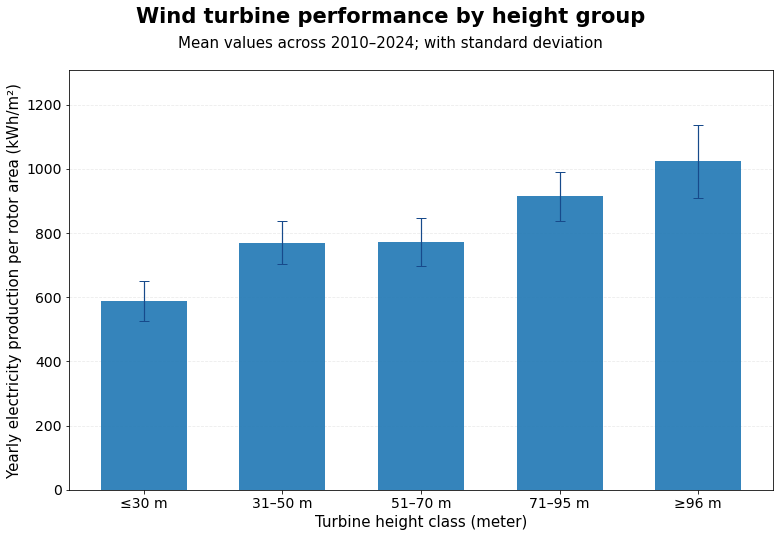

In [2]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. Configuration
# ============================================================
# CBS dataset:
# "Windenergie op land; productie en capaciteit naar ashoogte"
DATASET_ID = "71227ned"
BASE_URL = f"https://datasets.cbs.nl/odata/v1/CBS/{DATASET_ID}"

# Analysis period (Assumption: Data prior to 2010 has been excluded due to its incompleteness)
YEAR_START = 2010    
YEAR_END = 2024

# Desired display order of turbine height classes
ROW_ORDER = [
    "Totaal alle ashoogten",
    "t/m 30 meter",
    "31 t/m 50 meter",
    "51 t/m 70 meter",
    "71 t/m 95 meter",
    "96 meter of meer",
]

# Selected metric for analysis
TARGET_MEASURE = "Elektriciteitsproductie|Productie per rotoroppervlak|kWh per m2"

# ============================================================
# 2. Helper function to download paginated CBS OData tables
# ============================================================
def get_odata(url: str) -> pd.DataFrame:
    """
    Download all pages from a CBS OData endpoint and return the
    combined result as a single DataFrame.
    """
    frames = []

    while url:
        response = requests.get(url, timeout=60)
        response.raise_for_status()
        data = response.json()

        frames.append(pd.DataFrame(data["value"]))
        url = data.get("@odata.nextLink")

    if frames:
        return pd.concat(frames, ignore_index=True)

    return pd.DataFrame()

# ============================================================
# 3. Download raw data and metadata
# ============================================================
# Observations contain the numeric values.
# Metadata tables are used to decode measures, periods, and height classes.
observations = get_odata(f"{BASE_URL}/Observations")
measure_codes = get_odata(f"{BASE_URL}/MeasureCodes")
measure_groups = get_odata(f"{BASE_URL}/MeasureGroups")
height_codes = get_odata(f"{BASE_URL}/AshoogtenWindmolensCodes")
period_codes = get_odata(f"{BASE_URL}/PeriodenCodes")

# Basic validation
assert not observations.empty, "Observations table is empty."
assert "Value" in observations.columns, "Expected 'Value' column not found."

# ============================================================
# 4. Merge metadata into the observations table
# ============================================================
# Add readable labels for:
# - measures
# - measure groups
# - wind turbine height classes
# - time periods
df = observations.merge(
    measure_codes,
    left_on="Measure",
    right_on="Identifier",
    how="left",
    suffixes=("", "_measure")
)

df = df.merge(
    measure_groups[["Id", "Title"]].rename(columns={"Title": "MeasureGroupTitle"}),
    left_on="MeasureGroupId",
    right_on="Id",
    how="left"
)

df = df.merge(
    height_codes[["Identifier", "Title"]].rename(columns={"Title": "ShaftHeightTitle"}),
    left_on="AshoogtenWindmolens",
    right_on="Identifier",
    how="left"
)

df = df.merge(
    period_codes[["Identifier", "Title"]].rename(columns={"Title": "PeriodTitle"}),
    left_on="Perioden",
    right_on="Identifier",
    how="left"
)

# ============================================================
# 5. Extract year and filter the analysis period
# ============================================================
# CBS period labels may look like "2024**"; extract the year with regex.
period_text = df["PeriodTitle"].fillna("").astype(str)

df["Year"] = pd.to_numeric(
    period_text.str.extract(r"(\d{4})", expand=False),
    errors="coerce"
)

df = df[df["Year"].between(YEAR_START, YEAR_END)].copy()
df["Year"] = df["Year"].astype(int)

# ============================================================
# 6. Clean text fields used in filtering
# ============================================================
df["MeasureGroupTitle"] = df["MeasureGroupTitle"].fillna("").astype(str).str.strip()
df["Title"] = df["Title"].fillna("").astype(str).str.strip()

# ============================================================
# 7. Keep only the required measure
# ============================================================
def canonical_measure_name(group: str, title: str):
    """
    Map CBS measure metadata to the canonical measure label used
    in this analysis.
    """
    g = group.lower()
    t = title.lower()

    if "elektriciteitsproductie" in g and "productie per rotoroppervlak" in t:
        return "Elektriciteitsproductie|Productie per rotoroppervlak|kWh per m2"

    return None

df["MeasureLabel"] = df.apply(
    lambda row: canonical_measure_name(row["MeasureGroupTitle"], row["Title"]),
    axis=1
)

# Filter to the selected metric only
df = df[df["MeasureLabel"] == TARGET_MEASURE].copy()

# Sanity check after filtering
assert not df.empty, "Filtered dataset is empty. Check measure selection."

# ============================================================
# 8. Build a clean analysis table
# ============================================================
# Keep only the columns needed for the final summary and chart.
table = (
    df[["Year", "ShaftHeightTitle", "Value"]]
    .rename(columns={"Value": TARGET_MEASURE})
    .copy()
)

# Convert height class to an ordered categorical variable so sorting
# and plotting follow the intended sequence.
table["ShaftHeightTitle"] = pd.Categorical(
    table["ShaftHeightTitle"],
    categories=ROW_ORDER,
    ordered=True
)

table = table.sort_values(["Year", "ShaftHeightTitle"]).reset_index(drop=True)

# ============================================================
# 9. Remove missing values before aggregation
# ============================================================
table = table.dropna(subset=[TARGET_MEASURE]).copy()

# ============================================================
# 10. Summarize data by height class
# ============================================================
# For each turbine height class, calculate:
# - mean yearly electricity production per rotor area
# - year-to-year standard deviation
plot_table = (
    table
    .groupby("ShaftHeightTitle")
    .agg(
        avg_prod_area=(TARGET_MEASURE, "mean"),
        std_prod_area=(TARGET_MEASURE, "std"),
    )
    .reset_index()
)

# ============================================================
# 11. Remove the total row
# ============================================================
# Keep only the individual height classes for comparison.
plot_table = plot_table[
    plot_table["ShaftHeightTitle"] != "Totaal alle ashoogten"
].copy()

# ============================================================
# 12. Reapply logical ordering
# ============================================================
plot_table["ShaftHeightTitle"] = pd.Categorical(
    plot_table["ShaftHeightTitle"],
    categories=ROW_ORDER,
    ordered=True
)

plot_table = plot_table.sort_values("ShaftHeightTitle").reset_index(drop=True)

# ============================================================
# 13. Rename columns for readability
# ============================================================
plot_table = plot_table.rename(columns={
    "ShaftHeightTitle": "Turbine height class",
    "avg_prod_area": "Mean yearly electricity production per rotor area (kWh/m²)",
    "std_prod_area": "Year-to-year standard deviation (kWh/m²)"
})

# Round values for readability in table output
plot_table = plot_table.round(2)

# ============================================================
# 14. Plot style settings
# ============================================================
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 21,
    "axes.labelsize": 15,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.titleweight": "bold"
})

# ============================================================
# 15. Prepare chart inputs
# ============================================================
# Create numeric positions for the bars
x = np.arange(len(plot_table["Turbine height class"]))

# Translate Dutch category names into shorter display labels
height_translation = {
    "t/m 30 meter": "≤30 m",
    "31 t/m 50 meter": "31–50 m",
    "51 t/m 70 meter": "51–70 m",
    "71 t/m 95 meter": "71–95 m",
    "96 meter of meer": "≥96 m",
}

height_labels = plot_table["Turbine height class"].map(height_translation)

# Extract values for plotting
prod_area = plot_table["Mean yearly electricity production per rotor area (kWh/m²)"]
prod_area_std = plot_table["Year-to-year standard deviation (kWh/m²)"]

# ============================================================
# 16. Create the figure
# ============================================================
# Use a single bar chart with error bars to show both average
# performance and year-to-year variability by height class.
fig, ax = plt.subplots(figsize=(11, 8.0))

bar_color = "#1f77b4"

ax.bar(
    x,
    prod_area,
    width=0.62,
    color=bar_color,
    alpha=0.9,
    edgecolor="none",
    yerr=prod_area_std,
    capsize=5,
    error_kw={"elinewidth": 1.2, "ecolor": "#174a8b"}
)

# ============================================================
# 17. Configure axes and labels
# ============================================================
ax.set_xticks(x)
ax.set_xticklabels(height_labels)
ax.set_xlabel("Turbine height class (meter)")

ax.set_ylabel("Yearly electricity production per rotor area (kWh/m²)")
ax.set_ylim(0, (prod_area + prod_area_std).max() * 1.15)

# Add a subtle horizontal grid for readability
ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.25)
ax.set_axisbelow(True)

# ============================================================
# 18. Add title and subtitle
# ============================================================
fig.suptitle(
    "Wind turbine performance by height group",
    y=0.93,
    fontsize=21,
    fontweight="bold"
)

fig.text(
    0.5, 0.86,
    "Mean values across 2010–2024; with standard deviation",
    ha="center",
    fontsize=15
)

# ============================================================
# 19. Final layout and optional export
# ============================================================
plt.tight_layout(rect=[0, 0, 1, 0.9])

# Optional: save figure for slides or reports
# plt.savefig("rotor_area_productivity_by_height.png", dpi=300, bbox_inches="tight")

plt.show()